In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt


# --- PREP DATA ---
df_model = pd.read_parquet("../data/final_filtered.parquet")
df_model = df_model[df_model["WAGE_LEVEL_CLEAN"].isin(["I","II","III","IV"])]

# Filter to large employers ONLY (>1000 records)
top_employers = (
    df_model["EMPLOYER_NAME_CLEAN"]
    .value_counts()
    .loc[lambda x: x >= 1000]
    .index
)
df_model = df_model[df_model["EMPLOYER_NAME_CLEAN"].isin(top_employers)]
counts = (
    df_model
    .groupby(["EMPLOYER_NAME_CLEAN", "WAGE_LEVEL_CLEAN"])
    .size()
    .unstack(fill_value=0)
)

counts = counts[["I","II","III","IV"]]

Y = counts.values
N_emp, K = Y.shape

#MODEL FOR WAGE LEVEL DISTRIBUTION
with pm.Model() as model:
    #Prior on shared alpha_k
    alpha = pm.Exponential("alpha", 1.0, shape=K)

    # Employer-level distributions
    pi = pm.Dirichlet("pi", a=alpha, shape=(N_emp, K))

    # Likelihood
    obs = pm.Multinomial("obs", n=Y.sum(axis=1), p=pi, observed=Y)

    # --- VARIATIONAL INFERENCE ---
    approx = pm.fit(
        n=10000,            # increase to 20000 if needed
        method="advi"
    )

    trace = approx.sample(1000)

pi_mean = trace.posterior["pi"].mean(dim=("chain","draw")).values

emp_results = pd.DataFrame(
    pi_mean,
    index=counts.index,
    columns=["I","II","III","IV"]
)

# Low-level probability
emp_results["low_level_prob"] = emp_results["I"] + emp_results["II"]

# Top employers
print(emp_results.sort_values("low_level_prob", ascending=False).head(20))

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Output()

Finished [100%]: Average Loss = 35,991


                                           I        II       III        IV  \
EMPLOYER_NAME_CLEAN                                                          
grandison management                0.912627  0.058026  0.017756  0.011591   
collaborate solutions               0.124046  0.845465  0.019695  0.010795   
dallas independent school district  0.204513  0.764621  0.021378  0.009488   
eficens systems                     0.077191  0.887743  0.024958  0.010108   
management health systems           0.930652  0.031818  0.022707  0.014823   
atos syntel                         0.045528  0.916356  0.028171  0.009945   
tek leaders                         0.119666  0.842147  0.028435  0.009752   
tekorg                              0.024407  0.932399  0.025235  0.017960   
devereux foundation                 0.834557  0.121467  0.035175  0.008801   
tech mahindra americas              0.023261  0.931714  0.024064  0.020961   
persistent systems                  0.021860  0.931986  0.027641

                                           I        II       III        IV  \
EMPLOYER_NAME_CLEAN                                                          
grandison management                0.912627  0.058026  0.017756  0.011591   
collaborate solutions               0.124046  0.845465  0.019695  0.010795   
dallas independent school district  0.204513  0.764621  0.021378  0.009488   
eficens systems                     0.077191  0.887743  0.024958  0.010108   
management health systems           0.930652  0.031818  0.022707  0.014823   
atos syntel                         0.045528  0.916356  0.028171  0.009945   
tek leaders                         0.119666  0.842147  0.028435  0.009752   
tekorg                              0.024407  0.932399  0.025235  0.017960   
devereux foundation                 0.834557  0.121467  0.035175  0.008801   
tech mahindra americas              0.023261  0.931714  0.024064  0.020961   
persistent systems                  0.021860  0.931986  0.027641

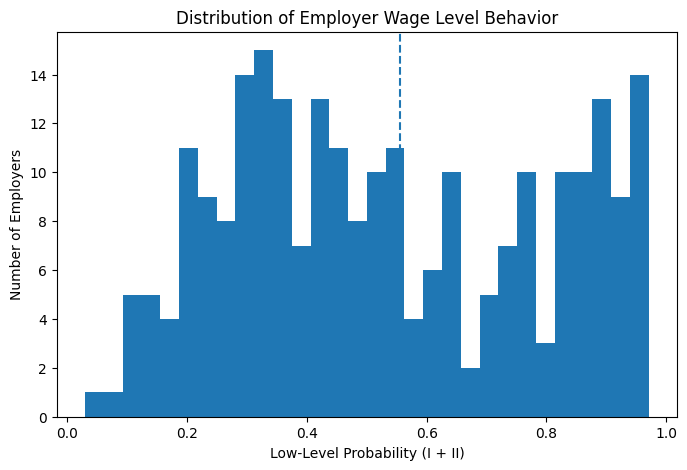

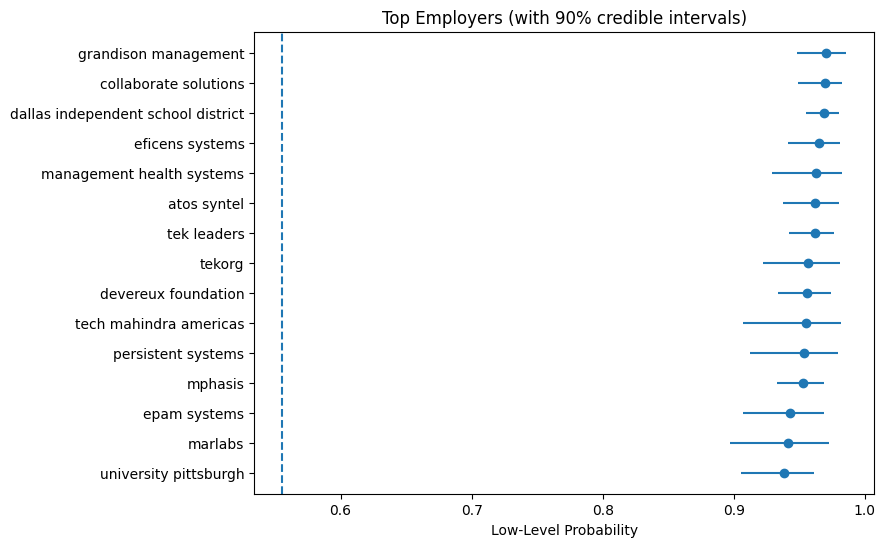

In [ ]:
global_dist = df_model["WAGE_LEVEL_CLEAN"].value_counts(normalize=True)
global_low = global_dist["I"] + global_dist["II"]

emp_results["low_level_excess"] = (
    emp_results["low_level_prob"] - global_low
)

top_employers = emp_results.sort_values(
    "low_level_excess", ascending=False
).head(20)

print(top_employers)

pi_samples = trace.posterior["pi"].stack(sample=("chain","draw"))
low_samples = pi_samples.isel(pi_dim_1=[0,1]).sum(dim="pi_dim_1")

emp_results["low_mean"] = low_samples.mean(dim="sample").values
emp_results["low_lower"] = low_samples.quantile(0.05, dim="sample").values
emp_results["low_upper"] = low_samples.quantile(0.95, dim="sample").values

plt.figure(figsize=(8,5))
plt.hist(emp_results["low_level_prob"], bins=30)
plt.axvline(global_low, linestyle="--")

plt.xlabel("Low-Level Probability (I + II)")
plt.ylabel("Number of Employers")
plt.title("Distribution of Employer Wage Level Behavior")

plt.show()

top = emp_results.sort_values("low_level_prob", ascending=False).head(15)

plt.figure(figsize=(8,6))

plt.errorbar(
    top["low_mean"],
    range(len(top)),
    xerr=[
        top["low_mean"] - top["low_lower"],
        top["low_upper"] - top["low_mean"]
    ],
    fmt="o"
)

plt.yticks(range(len(top)), top.index)
plt.axvline(global_low, linestyle="--")

plt.xlabel("Low-Level Probability")
plt.title("Top Employers (with 90% credible intervals)")

plt.gca().invert_yaxis()
plt.show()

In [ ]:
#NOW: FIT BUNCHING MODEL
df_model["near_threshold"] = df_model["wage_ratio"].between(0.99, 1.01).astype(int)

emp_counts = (
    df_model
    .groupby("EMPLOYER_NAME_CLEAN")
    .agg(
        N=("near_threshold", "size"),
        k=("near_threshold", "sum")
    )
)

N = emp_counts["N"].values
k = emp_counts["k"].values
n_emp = len(emp_counts)

with pm.Model() as bunch_model:
    #Global mean
    mu_B = pm.Normal("mu_B", 0, 2)

    # Employer variation
    sigma_B = pm.HalfNormal("sigma_B", 1)
    u_B = pm.Normal("u_B", 0, sigma_B, shape=n_emp)

    # Logit probability
    logit_theta = mu_B + u_B
    theta = pm.Deterministic("theta", pm.math.sigmoid(logit_theta))

    # Likelihood
    obs = pm.Binomial("obs", n=N, p=theta, observed=k)

    approx = pm.fit(10000, method="advi")
    trace_bunch = approx.sample(1000)

theta_mean = trace_bunch.posterior["theta"].mean(dim=("chain","draw")).values

emp_bunch = pd.DataFrame(
    {
        "bunch_rate_est": theta_mean,
        "N": N,
        "k": k
    },
    index=emp_counts.index
)

print(emp_bunch.sort_values("bunch_rate_est", ascending=False).head(20))

Output()

Finished [100%]: Average Loss = 15,326


                                   bunch_rate_est      N      k
EMPLOYER_NAME_CLEAN                                            
grandison management                     0.876843   3377   3371
marlabs                                  0.873640   1220   1188
cognizant technology solutions us        0.871284  89068  83998
deloitte touche llp                      0.867797   7439   6935
hcl global systems                       0.865149   2354   2169
deloitte tax llp                         0.854073   3717   3338
wipro                                    0.849434  14743  12954
skilltune technologies                   0.849091   1884   1664
netflix                                  0.804661   1279   1046
innova solutions                         0.746463   1235    926
tech mahindra americas                   0.673797  10227   6902
tek leaders                              0.673537   1100    744
sapphire software solutions              0.643757   1035    667
servicenow                              

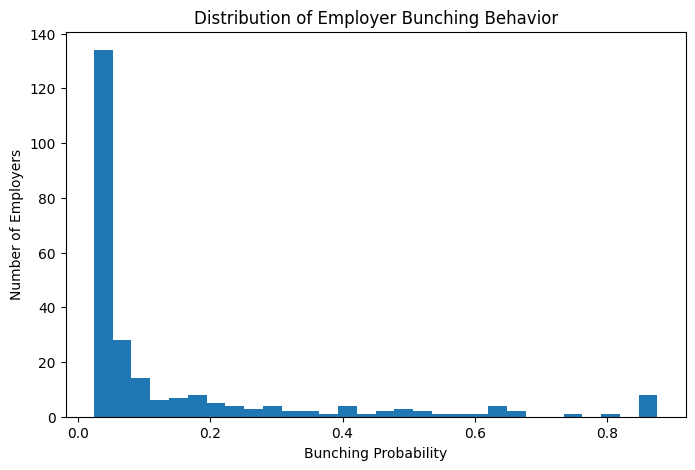

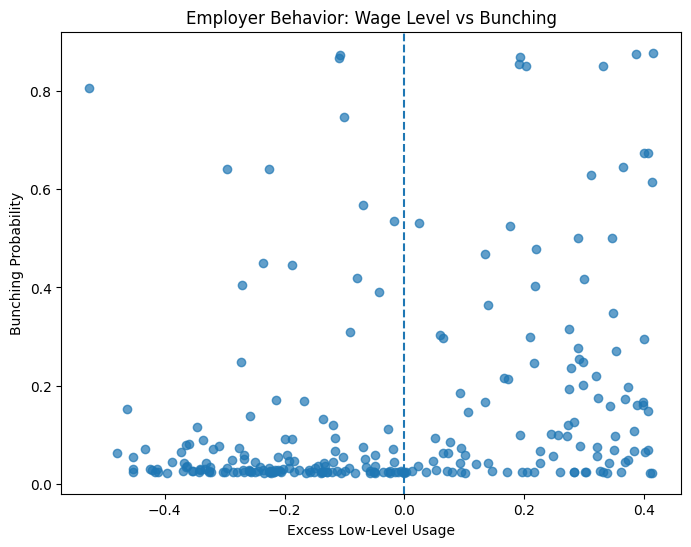

In [10]:
theta_samples = trace_bunch.posterior["theta"].stack(sample=("chain","draw"))

emp_bunch["theta_mean"] = theta_samples.mean(dim="sample").values
emp_bunch["theta_lower"] = theta_samples.quantile(0.05, dim="sample").values
emp_bunch["theta_upper"] = theta_samples.quantile(0.95, dim="sample").values

plt.figure(figsize=(8,5))
plt.hist(emp_bunch["theta_mean"], bins=30)

plt.xlabel("Bunching Probability")
plt.ylabel("Number of Employers")
plt.title("Distribution of Employer Bunching Behavior")

plt.show()

combined = emp_results.join(emp_bunch["theta_mean"])

combined = combined.dropna()

plt.figure(figsize=(8,6))

plt.scatter(
    combined["low_level_excess"],
    combined["theta_mean"],
    alpha=0.7
)

plt.axvline(0, linestyle="--")

plt.xlabel("Excess Low-Level Usage")
plt.ylabel("Bunching Probability")
plt.title("Employer Behavior: Wage Level vs Bunching")

plt.show()

In [ ]:
print(np.corrcoef(combined["low_level_excess"],combined["theta_mean"]))

X = sm.add_constant(combined["low_level_prob"])
y = combined["theta_mean"]

model = sm.OLS(y, X).fit()
print(model.summary())

#There is definitely evidence of some kind of positive relationship between bunching behavior and extra low level reporting

[[1.         0.29461037]
 [0.29461037 1.        ]]
                            OLS Regression Results                            
Dep. Variable:             theta_mean   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     23.48
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.24e-06
Time:                        12:08:51   Log-Likelihood:                 50.213
No. Observations:                 249   AIC:                            -96.43
Df Residuals:                     247   BIC:                            -89.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------